# 🏦 Customer Segmentation for Targeted Banking Products
**Dataset:** `messy_south_african_bank_dataset.csv`  
**Methods:** K-Means · Hierarchical Clustering · PCA  
**Goal:** Identify natural customer groups and recommend banking products per segment

---
## 1. Setup & Imports


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler


---
## 2. Load & Explore Data


### 2.1 Load the dataset

In [ ]:
# Load the dataset
banking_df = pd.read_csv("messy_south_african_bank_dataset.csv")
print(f"Dataset shape: {banking_df.shape}")
print(banking_df.head(10))


Dataset shape: (31, 16)
   Customer_ID  Age  Gender       Province Employment_Status  \
0         1001   34    Male   Western Cape          Employed   
1         1002   29  Female        Gauteng          Employed   
2         1003   45    Male            KZN     Self-Employed   
3         1004   52  Female   Eastern Cape        Unemployed   
4         1005   39    Male        Gauteng          Employed   
5         1005   39    Male        Gauteng          Employed   
6         1006   23  Female   Western Cape          Employed   
7         1007   31    Male        Limpopo     Self-Employed   
8         1008   47  Female     Free State          Employed   
9         1009   55    Male  Northern Cape        Unemployed   

   Monthly_Income_ZAR Account_Type  Account_Balance_ZAR  Monthly_Transactions  \
0             25000.0       Cheque              12000.0                    45   
1                 NaN      Savings               8000.0                    30   
2             22000.0       

In [ ]:
# Checking the data types and information
banking_df.info()
banking_df.dtypes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                31 non-null     int64  
 1   Age                        31 non-null     int64  
 2   Gender                     31 non-null     object 
 3   Province                   31 non-null     object 
 4   Employment_Status          31 non-null     object 
 5   Monthly_Income_ZAR         30 non-null     float64
 6   Account_Type               31 non-null     object 
 7   Account_Balance_ZAR        30 non-null     float64
 8   Monthly_Transactions       31 non-null     int64  
 9   Avg_Transaction_Value_ZAR  31 non-null     int64  
 10  Loan_Status                31 non-null     object 
 11  Loan_Amount_ZAR            31 non-null     int64  
 12  Credit_Score               30 non-null     float64
 13  Missed_Payments_Last_6M    31 non-null     int64  
 

Customer_ID                    int64
Age                            int64
Gender                        object
Province                      object
Employment_Status             object
Monthly_Income_ZAR           float64
Account_Type                  object
Account_Balance_ZAR          float64
Monthly_Transactions           int64
Avg_Transaction_Value_ZAR      int64
Loan_Status                   object
Loan_Amount_ZAR                int64
Credit_Score                 float64
Missed_Payments_Last_6M        int64
Digital_Banking_Usage         object
Customer_Tenure_Years          int64
dtype: object

In [ ]:
# Checking summary statistics
banking_df.describe()


,Customer_ID,Age,Monthly_Income_ZAR,Account_Balance_ZAR,Monthly_Transactions,Avg_Transaction_Value_ZAR,Loan_Amount_ZAR,Credit_Score,Missed_Payments_Last_6M,Customer_Tenure_Years
count,31.000000,31.000000,30.000000,30.000000,31.000000,31.000000,31.000000,30.000000,31.000000,31.000000
mean,1015.161290,37.806452,18456.666667,8250.000000,36.419355,290.483871,57322.580645,654.666667,1.548387,5.677419
std,8.858505,9.638186,8794.460770,6573.706769,18.282549,127.497417,53998.387073,78.002358,1.728944,3.026407
min,1001.000000,23.000000,4000.000000,1000.000000,7.000000,120.000000,0.000000,500.000000,0.000000,2.000000
25%,1007.500000,29.500000,13125.000000,2775.000000,21.500000,195.000000,0.000000,616.250000,0.000000,3.000000
50%,1015.000000,37.000000,20500.000000,5500.000000,35.000000,260.000000,50000.000000,692.500000,1.000000,5.000000
75%,1022.500000,45.500000,25750.000000,12750.000000,52.500000,402.500000,92500.000000,708.750000,2.500000,7.000000
max,1030.000000,55.000000,31000.000000,21000.000000,60.000000,520.000000,160000.000000,750.000000,5.000000,12.000000


### 2.2 Data quality checks

In [ ]:
# Checking for missing values
banking_df.isnull().sum().sum()
missing_values_count = banking_df.isnull().sum()
missing_values_percent = (missing_values_count / len(banking_df)) * 100
missing_values_df = pd.DataFrame({
    'Missing Values': missing_values_count,
    'Percentage Missing': missing_values_percent
})
print(missing_values_df)

# Filter to show only columns with missing values
missing_values_df[missing_values_df['Missing Values'] > 0]


                           Missing Values  Percentage Missing
Customer_ID                             0            0.000000
Age                                     0            0.000000
Gender                                  0            0.000000
Province                                0            0.000000
Employment_Status                       0            0.000000
Monthly_Income_ZAR                      1            3.225806
Account_Type                            0            0.000000
Account_Balance_ZAR                     1            3.225806
Monthly_Transactions                    0            0.000000
Avg_Transaction_Value_ZAR               0            0.000000
Loan_Status                             0            0.000000
Loan_Amount_ZAR                         0            0.000000
Credit_Score                            1            3.225806
Missed_Payments_Last_6M                 0            0.000000
Digital_Banking_Usage                   0            0.000000
Customer

,Missing Values,Percentage Missing
Monthly_Income_ZAR,1,3.225806
Account_Balance_ZAR,1,3.225806
Credit_Score,1,3.225806


In [ ]:
# Checking for duplicate Customer_IDs
duplicate_ids = banking_df.duplicated(subset=['Customer_ID'], keep=False)
print(f"Number of duplicate Customer_IDs: {duplicate_ids.sum()}")

Number of duplicate Customer_IDs: 2
Duplicate Customer_IDs:


In [ ]:
# Define the mapping dictionary
usage_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

# Apply mapping directly on the object column
banking_df['Digital_Banking_Usage_Encoded'] = banking_df['Digital_Banking_Usage'].map(usage_mapping)

# Check the new column and its data type
banking_df['Digital_Banking_Usage_Encoded'] = banking_df['Digital_Banking_Usage_Encoded'].astype('int64')


In [ ]:
# Printing digitial banking usage encoded column and Loan status
print(banking_df[['Digital_Banking_Usage_Encoded', 'Loan_Status']].head())

   Digital_Banking_Usage_Encoded  Loan_Status
0                              2  Active Loan
1                              2      No Loan
2                              1  Active Loan
3                              0    Defaulted
4                              2  Active Loan


In [ ]:
# Checking value counts for categorical columns
categorical_columns = ['Province', 'Employment_Status', 'Account_Type', 'Loan_Status', 'Digital_Banking_Usage']
for column in categorical_columns:
    print(f"Value counts for {column}:")
    print(banking_df[column].value_counts())
    print("\n")


Value counts for Province:
Province
Gauteng          9
Western Cape     7
Eastern Cape     3
Limpopo          3
Free State       3
Northern Cape    3
KZN              1
GP               1
Kwazulu-Natal    1
Name: count, dtype: int64


Value counts for Employment_Status:
Employment_Status
Employed         19
Self-Employed     6
Unemployed        6
Name: count, dtype: int64


Value counts for Account_Type:
Account_Type
Cheque     12
Savings    12
Credit      7
Name: count, dtype: int64


Value counts for Loan_Status:
Loan_Status
Active Loan    16
No Loan         9
Defaulted       6
Name: count, dtype: int64


Value counts for Digital_Banking_Usage:
Digital_Banking_Usage
High      17
Medium     8
Low        6
Name: count, dtype: int64




### 2.3 Visualise distributions

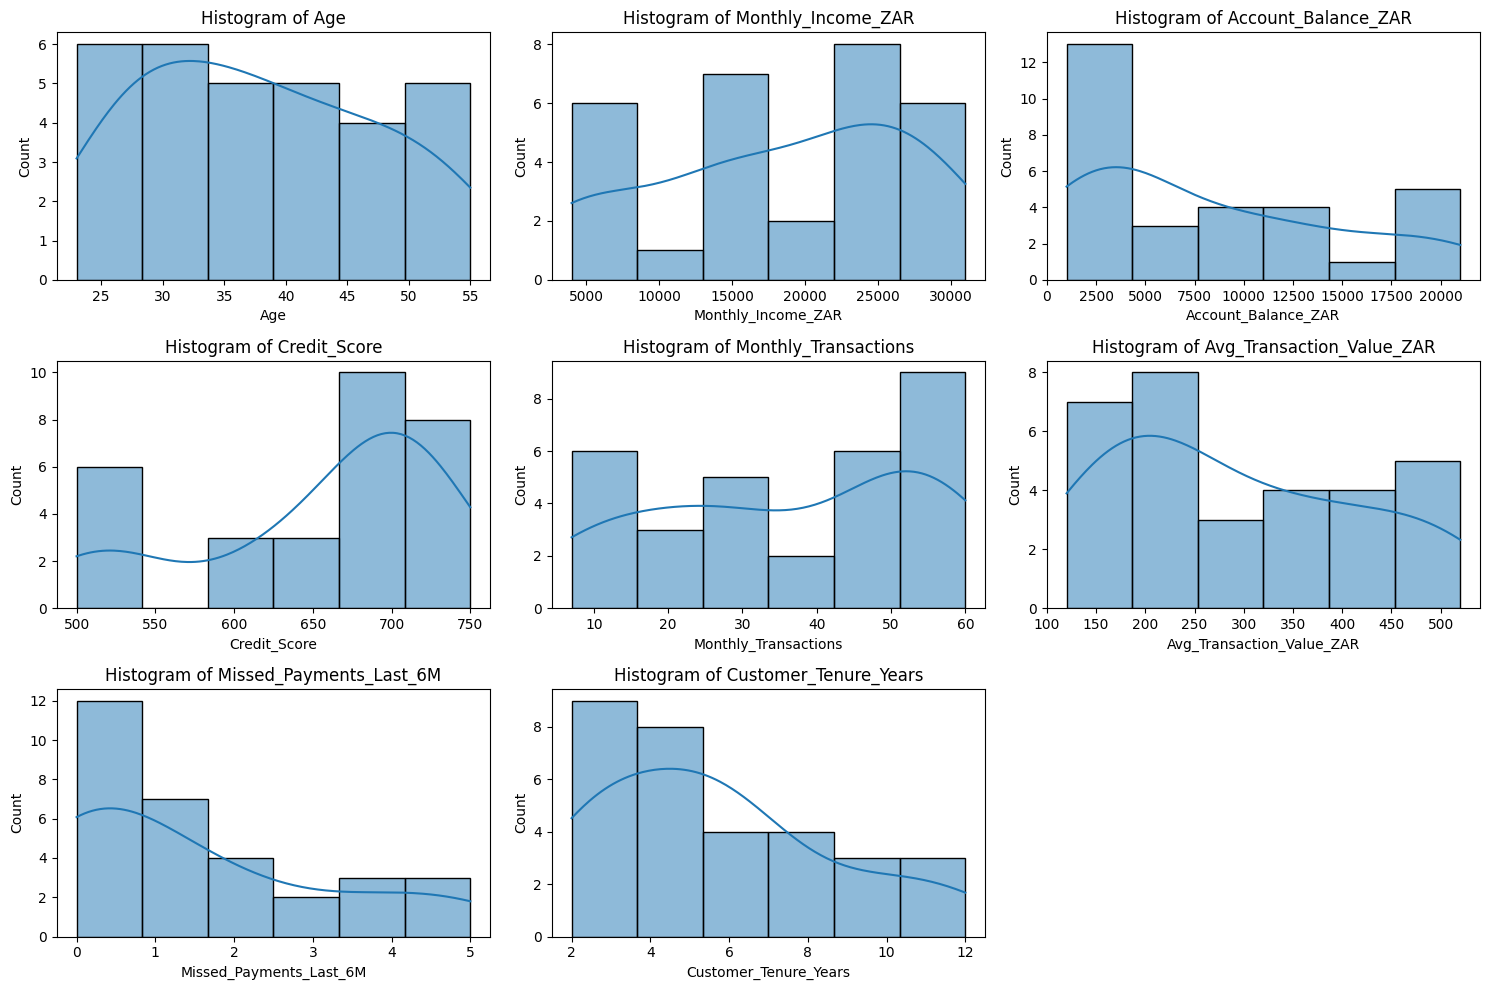

In [ ]:
# Visualize distributions of numeric columns
plt.figure(figsize=(15, 10))
numeric_columns = ['Age', 'Monthly_Income_ZAR', 'Account_Balance_ZAR', 'Credit_Score',
                   'Monthly_Transactions', 'Avg_Transaction_Value_ZAR',
                   'Missed_Payments_Last_6M', 'Customer_Tenure_Years']
for i, column in enumerate(numeric_columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(banking_df[column].dropna(), kde=True)
    plt.title(f'Histogram of {column}')
plt.tight_layout()
plt.show()

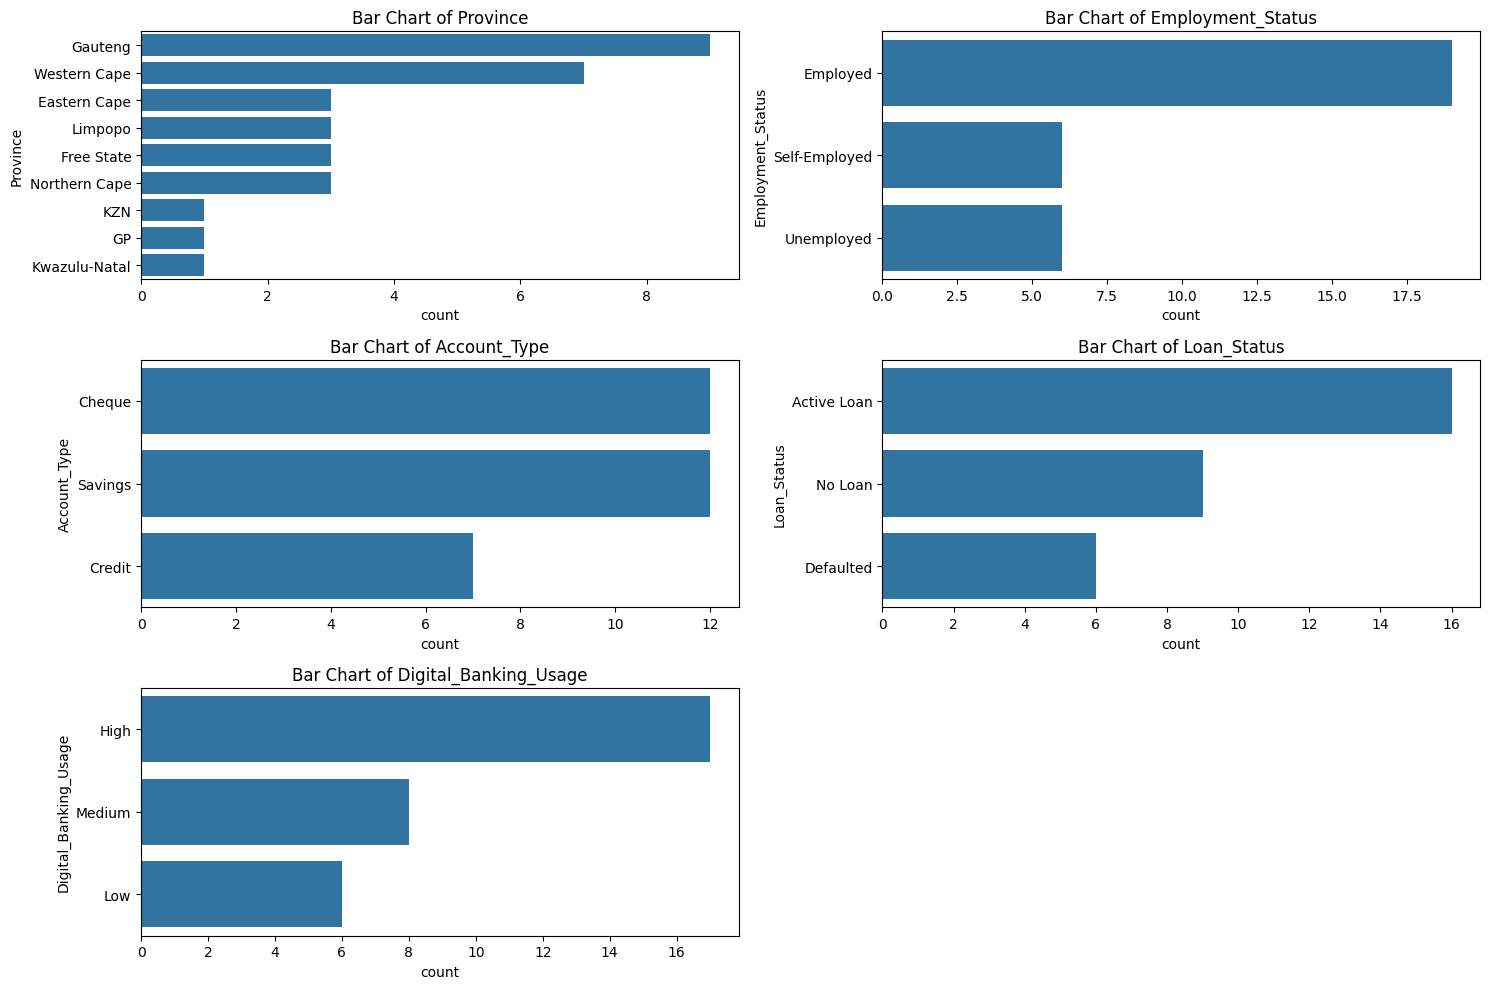

In [ ]:
# Visualize distributions of categorical columns
plt.figure(figsize=(15, 10))
numeric_columns = ['Province', 'Employment_Status', 'Account_Type', 'Loan_Status', 'Digital_Banking_Usage']
for i, column in enumerate(numeric_columns):
    plt.subplot(3, 2, i + 1)
    sns.countplot(y=banking_df[column], order=banking_df[column].value_counts().index)
    plt.title(f'Bar Chart of {column}')
plt.tight_layout()
plt.show()


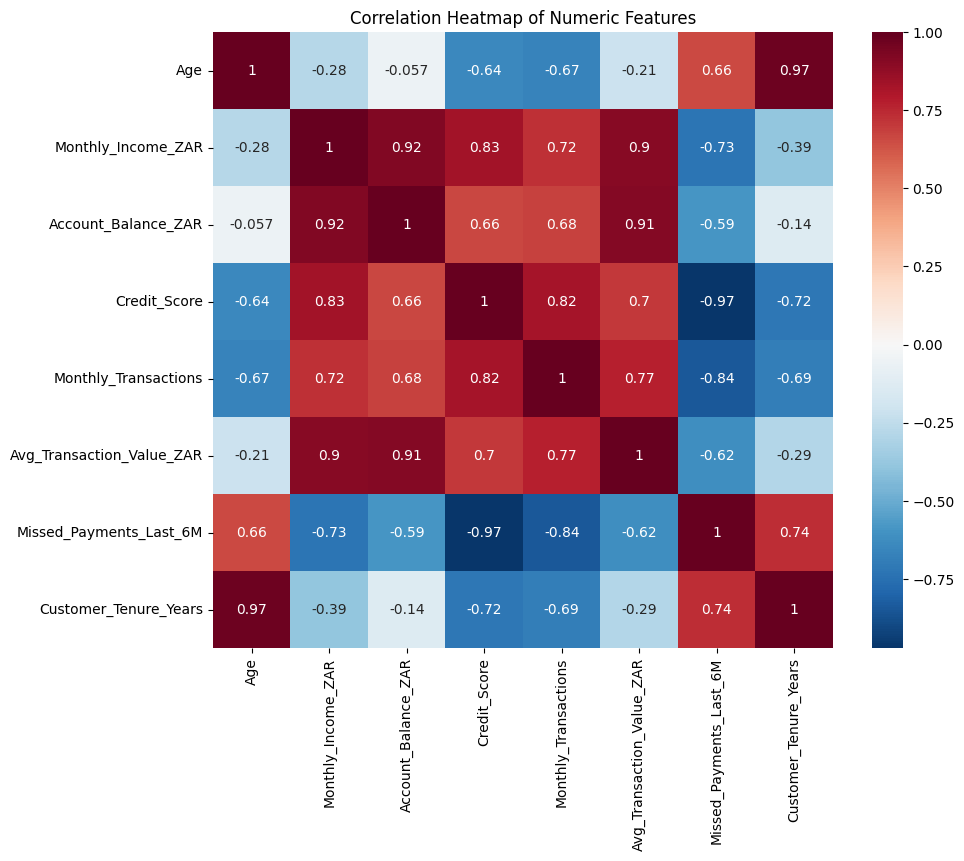

In [ ]:
# Correlation heatmap for numeric features
plt.figure(figsize=(10, 8))
numeric_columns = ['Age', 'Monthly_Income_ZAR', 'Account_Balance_ZAR', 'Credit_Score',
                   'Monthly_Transactions', 'Avg_Transaction_Value_ZAR',
                   'Missed_Payments_Last_6M', 'Customer_Tenure_Years']
correlation_matrix = banking_df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

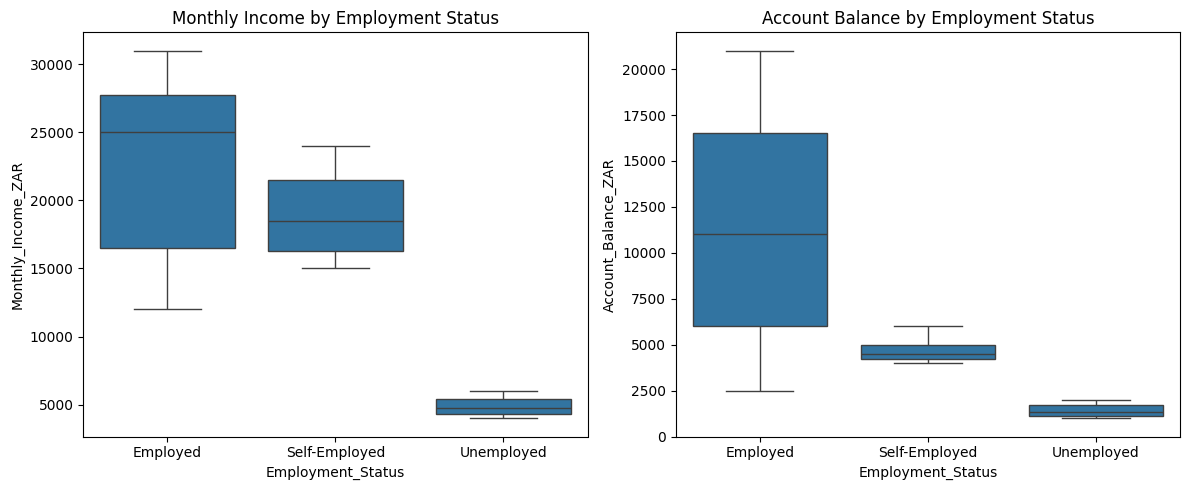

In [ ]:
# Box plots for numeric features by Employment Status
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Employment_Status', y='Monthly_Income_ZAR', data=banking_df)
plt.title('Monthly Income by Employment Status')
plt.subplot(1, 2, 2)
sns.boxplot(x='Employment_Status', y='Account_Balance_ZAR', data=banking_df)
plt.title('Account Balance by Employment Status')
plt.tight_layout()
plt.show()


### 2.4 Observations

In [ ]:
The dataset reveals two distinct customer segments. Most customers are financially strong, active, and digitally engaged, while a smaller group is financially vulnerable, less active, and prone to missed payments. Numeric features show skewed distributions in income, balances, and credit scores, with clear differences by employment status. Categorical data highlights dominance of Gauteng and Western Cape, employed status, and high digital usage. Correlations confirm that financial health (income, balance, credit, transactions, digital usage) is inversely related to missed payments. Clustering methods (K-Means, hierarchical) consistently identify two stable groups: high-value customers and low-value, at-risk customers. PCA further validates this split, with PC1 capturing financial strength and engagement as the main axis of separation.

---
## 3. Data Cleaning


### 3.1 Remove duplicates

In [ ]:
# Drop duplicate Customer ID, and keeping the first instance
banking_df = banking_df.drop_duplicates(subset=['Customer_ID'], keep='first')
print(f"Row count before dropping duplicates: {banking_df.shape[0]}")
print(f"Row count after dropping duplicates: {banking_df.shape[0]}")


Row count before dropping duplicates: 30
Row count after dropping duplicates: 30


### 3.2 Standardise province names

In [ ]:
# Remove leading and trailing white spaces
banking_df['Province'] = banking_df['Province'].str.lstrip()
banking_df['Province'] = banking_df['Province'].str.rstrip()

In [ ]:
# Fix province variants
banking_df['Province'] = banking_df['Province'].replace({
    'GP': 'Gauteng',
    'KZN': 'KwaZulu-Natal',
    'Kwazulu-Natal': 'KwaZulu-Natal'
})
provinces = banking_df['Province'].unique()
print(f"There are {len(provinces)} unique provinces")
provinces

There are 7 unique provinces


array(['Western Cape', 'Gauteng', 'KwaZulu-Natal', 'Eastern Cape',
       'Limpopo', 'Free State', 'Northern Cape'], dtype=object)

### 3.3 Impute missing values

In [ ]:
# Impute missing values for numeric columns using median
banking_df['Monthly_Income_ZAR'] = banking_df['Monthly_Income_ZAR'].fillna(banking_df['Monthly_Income_ZAR'].median())
banking_df['Credit_Score'] = banking_df['Credit_Score'].fillna(banking_df['Credit_Score'].median())
banking_df['Account_Balance_ZAR'] = banking_df['Account_Balance_ZAR'].fillna(banking_df['Account_Balance_ZAR'].median())
print(banking_df[['Monthly_Income_ZAR', 'Credit_Score', 'Account_Balance_ZAR']].isnull().sum()) 

Monthly_Income_ZAR     0
Credit_Score           0
Account_Balance_ZAR    0
dtype: int64


### 3.4 Observations

The dataset underwent several cleaning steps to improve accuracy and consistency. Duplicate Customer_IDs were removed to ensure unique records. Province names were standardized by trimming whitespace and aligning all variants to official names. Missing numeric values in income, credit score, and account balance were imputed using medians to retain all rows. Cases with active loans but zero loan amounts were corrected by filling missing values with zero to avoid calculation errors. Right-skewed numeric distributions were normalized using StandardScaler to balance feature influence during clustering. Finally, all data types were verified as correct, confirming no conversion issues.

---
## 4. Feature Engineering

### 4.1 Encode categorical features

In [ ]:
# Encode Digital_Banking_Usage using mapping
mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}
banking_df['Digital_Usage_Enc'] = banking_df['Digital_Banking_Usage'].map(mapping)

In [ ]:
# Create binary features for Employment Status and Loan Status
banking_df['Is_Employed'] = (banking_df['Employment_Status'] == 'Employed').astype(int)
banking_df['Is_SelfEmployed'] = (banking_df['Employment_Status'] == 'Self-Employed').astype(int)
banking_df['Has_Loan'] = (banking_df['Loan_Status'] != 'No Loan').astype(int)
banking_df['Is_Defaulted'] = (banking_df['Loan_Status'] == 'Defaulted').astype(int)


In [ ]:
# Create dummy variables for Account_Type
account_dummies = pd.get_dummies(banking_df['Account_Type'], prefix='AccType', drop_first=False)
banking_df = pd.concat([banking_df, account_dummies], axis=1)


### 4.2 Create ratio features

In [77]:
# Balance-to-Income Ratio = Account_Balance_ZAR / (Monthly_Income_ZAR + 1)
# Captures savings behaviour relative to earnings
banking_df['Balance_Income_Ratio'] = banking_df['Account_Balance_ZAR'] / (banking_df['Monthly_Income_ZAR'] + 1)


In [80]:
# Loan-to-Annual-Income Ratio = Loan_Amount_ZAR / (Monthly_Income_ZAR * 12 + 1)
# Captures debt burden
banking_df['Loan_Amount_ZAR'] = banking_df['Loan_Amount_ZAR'].fillna(0)
banking_df['Loan_Annual_Income_Ratio'] = banking_df['Loan_Amount_ZAR'] / (banking_df['Monthly_Income_ZAR'] * 12 +1)


In [81]:
# Transaction Intensity = Monthly_Transactions * Avg_Transaction_Value_ZAR
# Captures total monthly account activity value
banking_df['Transaction_Intensity'] = banking_df['Monthly_Transactions'] * banking_df['Avg_Transaction_Value_ZAR']


In [82]:
# Payment Reliability = 1 / (Missed_Payments_Last_6M + 1)
# Inverse score — higher means more reliable payer
banking_df['Payment_Reliability'] = 1 / (banking_df['Missed_Payments_Last_6M'] + 1)


In [ ]:
# Preview the four new ratio columns with .describe()
print(banking_df[['Balance_Income_Ratio', 'Loan_Annual_Income_Ratio', 'Transaction_Intensity', 'Payment_Reliability']].describe())

       Balance_Income_Ratio  Loan_Annual_Income_Ratio  Transaction_Intensity  \
count             30.000000                 30.000000              30.000000   
mean               0.376110                  0.255197           11735.666667   
std                0.153196                  0.178500            9255.485581   
min                0.192293                  0.000000             875.000000   
25%                0.252947                  0.000000            4185.000000   
50%                0.313599                  0.329706           10765.000000   
75%                0.473617                  0.398449           14400.000000   
max                0.677398                  0.499992           31200.000000   

       Payment_Reliability  
count            30.000000  
mean              0.581111  
std               0.342006  
min               0.166667  
25%               0.270833  
50%               0.500000  
75%               1.000000  
max               1.000000  


The ratio features were engineered to turn raw financial numbers into behaviour signals with a clearer business meaning.

The balance_Income_Ratio shows how much of a customer’s monthly earning is sitting in their account balance. A higher ratio implies better savings or cash reserves relative to income.
The loan_Annual_Income_Ratio captures debt burden relative to annual income. It is more useful than Loan_Amount_ZAR alone because it scales loan size by the customer’s ability to repay.
The transaction_Intensity measures total monthly activity value, combining how often a customer transacts with how much they typically spend each time.
The payment Reliability inverts missed payments so that fewer missed payments become a higher reliability score, making payment behaviour easier to compare across customers.

In the output summary, these ratios help make the clusters more meaningful. One segment has a much higher average income (≈21,400 ZAR), larger balances (≈9,329 ZAR) and very few missed payments (≈0.88), which aligns with stronger Balance_Income_Ratio and Payment_Reliability values. The other segment has a lower average income (≈4,867 ZAR), smaller balances (≈1,433 ZAR) and far more missed payments (≈4.5), highlighting a more vulnerable debt profile and lower financial stability.

The purpose of these ratios is to add a more meaningful data contribution: they transform raw features into indicators of savings strength, debt burden, engagement and repayment reliability, helping clustering separate customers by behaviour rather than by raw magnitude alone.

---
## 5. Feature Selection & Scaling


### 5.1 Define your feature list

In [ ]:
# Define CLUSTER_FEATURES as a list of column names to use
CLUSTER_FEATURES = [
    'Age', 'Monthly_Income_ZAR', 'Account_Balance_ZAR', 'Credit_Score',
    'Monthly_Transactions', 'Digital_Usage_Enc', 'Customer_Tenure_Years',
    'Missed_Payments_Last_6M', 'Balance_Income_Ratio',
    'Transaction_Intensity', 'Payment_Reliability'
]
X = banking_df[CLUSTER_FEATURES].copy()
print(f"Clustering feature set shape: {X.shape}")
print(f"Clustering features: {X.columns.tolist()}") 

# Removing the four engineered ratio features to see how it affects clustering results
CLUSTER_FEATURES = [
    'Age', 'Monthly_Income_ZAR', 'Account_Balance_ZAR', 'Credit_Score',
    'Monthly_Transactions', 'Digital_Usage_Enc', 'Customer_Tenure_Years',
    'Missed_Payments_Last_6M'
]
X = banking_df[CLUSTER_FEATURES].copy()
print(f"Clustering feature set shape: {X.shape}")
print(f"Clustering features: {X.columns.tolist()}")


Clustering feature set shape: (30, 11)
Clustering features: ['Age', 'Monthly_Income_ZAR', 'Account_Balance_ZAR', 'Credit_Score', 'Monthly_Transactions', 'Digital_Usage_Enc', 'Customer_Tenure_Years', 'Missed_Payments_Last_6M', 'Balance_Income_Ratio', 'Transaction_Intensity', 'Payment_Reliability']
Clustering feature set shape: (30, 8)
Clustering features: ['Age', 'Monthly_Income_ZAR', 'Account_Balance_ZAR', 'Credit_Score', 'Monthly_Transactions', 'Digital_Usage_Enc', 'Customer_Tenure_Years', 'Missed_Payments_Last_6M']


### 5.2 Scale with StandardScaler

In [ ]:
#Fit StandardScalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
# Preview the scaled features with .describe()
print(X_scaled_df.describe())


                Age  Monthly_Income_ZAR  Account_Balance_ZAR  Credit_Score  \
count  3.000000e+01        3.000000e+01         3.000000e+01  3.000000e+01   
mean   1.073216e-16        1.443290e-16        -2.220446e-17 -4.810966e-16   
std    1.017095e+00        1.017095e+00         1.017095e+00  1.017095e+00   
min   -1.532505e+00       -1.684562e+00        -1.105619e+00 -2.017032e+00   
25%   -8.838714e-01       -5.961767e-01        -8.148824e-01 -4.977233e-01   
50%   -1.314564e-01        2.238396e-01        -4.504375e-01  4.661391e-01   
75%    8.285213e-01        8.202151e-01         6.551818e-01  7.111889e-01   
max    1.788499e+00        1.535866e+00         2.170290e+00  1.250298e+00   

       Monthly_Transactions  Digital_Usage_Enc  Customer_Tenure_Years  \
count          3.000000e+01       3.000000e+01           3.000000e+01   
mean           1.850372e-17       8.141636e-17          -9.251859e-17   
std            1.017095e+00       1.017095e+00           1.017095e+00   
min  

---
## 6. Finding the Optimal Number of Clusters

### 6.1 Compute metrics across K values

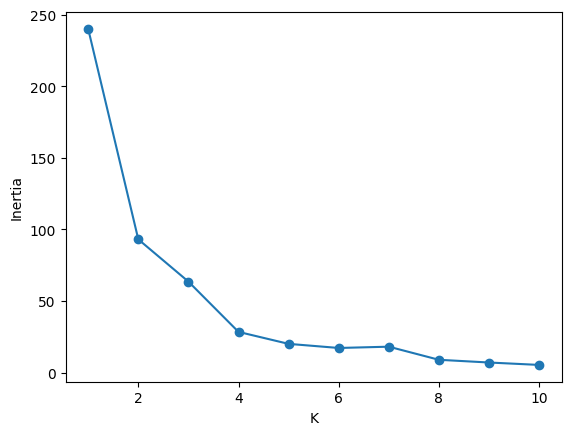

In [ ]:
rseed = 42

# Plot elbow curve
def eval_Kmeans(x, k, r):
    kmeans = KMeans(n_clusters=k, random_state=r, max_iter=500)
    kmeans.fit(x)
    return kmeans.inertia_

def elbow_Kmeans(x, max_k=10, r=42):
    within_cluster_vars = [eval_Kmeans(x, k, r) for k in range(1, max_k+1)]
    plt.plot(range(1, 11), within_cluster_vars,marker='o')
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.show()

# Plot elbow curve using scaled dataset
elbow_Kmeans(X_scaled_df, max_k=10, r=rseed)


### 6.2 Elbow plot

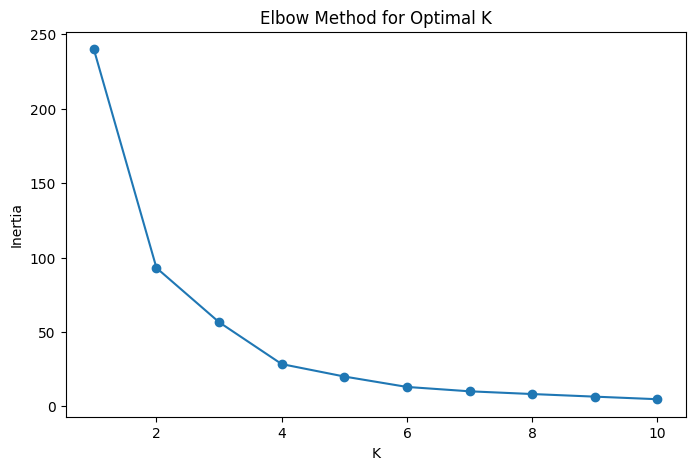

In [ ]:
# Plot elbow curve using scaled dataset
plt.figure(figsize=(8, 5))
K_RANGE = range(1, 11)
inertias = []
for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=rseed, n_init=10)
    kmeans.fit(X_scaled_df)
    inertias.append(kmeans.inertia_)

plt.plot(K_RANGE, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

### 6.3 Silhouette bar chart

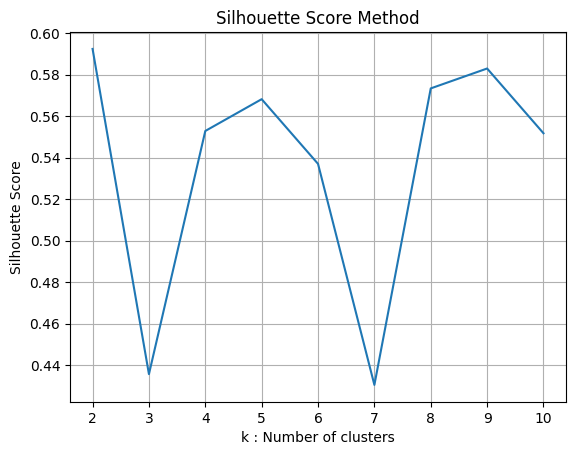

In [ ]:
# Plot silhouette scores for K=2 to 10
kmax = 10
sil = []
plt.plot()
for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters=k, random_state=rseed, max_iter=500)
    kmeans.fit(X_scaled_df)
    labels = kmeans.labels_
    sil.append(silhouette_score(X_scaled_df, labels, metric='euclidean'))

sns.lineplot(x=range(2, kmax+1), y=sil)
plt.title('Silhouette Score Method')
plt.xlabel('k : Number of clusters')
plt.ylabel("Silhouette Score")
plt.grid(visible=True)
plt.show()


### 6.4 Set final K

In [110]:
k = 2

From both the elblow plot and elbow curve, the optimal choice for K appears to be 5, as the rate of decline notice=able flattens beyond that point. However, the Silhouette score method points in a different direction, indicating that K= 2 yields the strongest clustering structure, with the highest score of 0.59

---
## 7. K-Means Clustering

### 7.1 Fit K-Means

In [ ]:
# Train final KMeans model with chosen k on scaled dataset
kmeans = KMeans(n_clusters=k, random_state=rseed, max_iter=500)
kmeans.fit(X_scaled_df)

print(f"trained k-means with k={k}, inertia={kmeans.inertia_}")

# Reserving the labels
labels = kmeans.labels_


trained k-means with k=2, inertia=93.00593871534548


### 7.2 Cluster size distribution

KMeans_Cluster
0    24
1     6
Name: count, dtype: int64


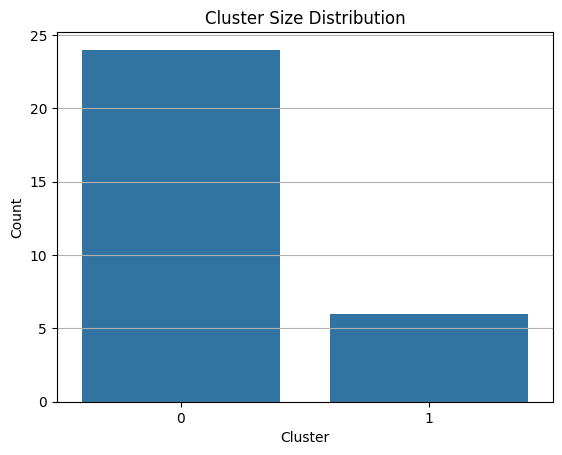

In [ ]:
# Add labels to df as column 'KMeans_Cluster'
banking_df['KMeans_Cluster'] = labels
print(banking_df['KMeans_Cluster'].value_counts())
sns.countplot(x='KMeans_Cluster', data=banking_df)
plt.title('Cluster Size Distribution')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.grid(visible=True, axis='y')
plt.show()


### 7.3 Silhouette plot for final K

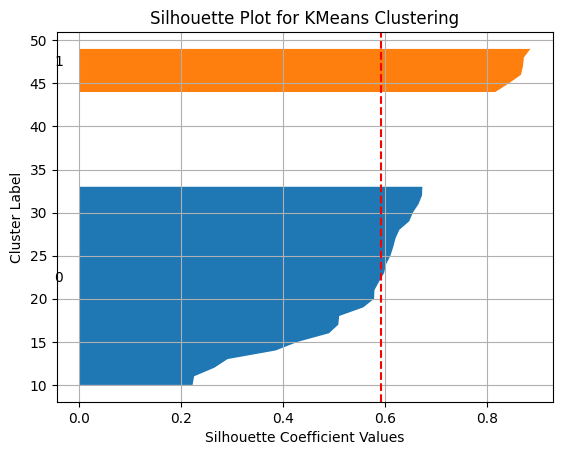

In [ ]:
# Compute per-sample silhouette scores with silhouette_samples
silhouette_vals = silhouette_samples(X_scaled_df, labels)
y_lower = 10
for i in range(k):
    ith_cluster_silhouette_vals = silhouette_vals[labels == i]
    ith_cluster_silhouette_vals.sort()
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_vals)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # 10 for spacing between clusters
plt.title('Silhouette Plot for KMeans Clustering')
plt.xlabel('Silhouette Coefficient Values')
plt.ylabel('Cluster Label')
plt.axvline(x=silhouette_score(X_scaled_df, labels), color="red", linestyle="--")
plt.grid(visible=True)
plt.show()


### 7.4 Cluster centres

In [ ]:
# Print km.cluster_centers_ as a DataFrame
centers_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
centers_original = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=X.columns)
print("Cluster Centers (Scaled):")
print(centers_scaled)
print("\nCluster Centers (Original Scale):")
print(centers_original)


Cluster Centers (Scaled):
        Age  Monthly_Income_ZAR  Account_Balance_ZAR  Credit_Score  \
0 -0.369289            0.395298             0.258660      0.447080   
1  1.477155           -1.581190            -1.034641     -1.788319   

   Monthly_Transactions  Digital_Usage_Enc  Customer_Tenure_Years  \
0              0.368054           0.422577              -0.413112   
1             -1.472215          -1.690309               1.652447   

   Missed_Payments_Last_6M  
0                -0.425246  
1                 1.700985  

Cluster Centers (Original Scale):
         Age  Monthly_Income_ZAR  Account_Balance_ZAR  Credit_Score  \
0  34.208333        21437.500000          9329.166667    688.541667   
1  52.000000         4866.666667          1433.333333    517.500000   

   Monthly_Transactions  Digital_Usage_Enc  Customer_Tenure_Years  \
0             42.166667           1.666667               4.416667   
1              9.500000           0.000000              10.666667   

   Missed_P

### 7.5 Observations

With a Silhouette score of just below 0.6, we see that a moderately strong clustering solution is present. The cluster sizes are similarly balanced in length, while they have starkly different widths, with cluster 1 being more narrow indicating that there are fewer cluster points compared to the second cluster. The two centres are very different from one another. The one is younger, more digitally active and less financially constrained. The other is more mature, with a lower income, and less digitally engagaed.

---
## 8. Hierarchical Clustering & Dendrogram
An alternative that doesn't require specifying K upfront.

### 8.1 Compute linkage matrix

In [ ]:
# Compute: linkage(X_scaled, method='ward')
linked = linkage(X_scaled, method='ward')


### 8.2 Plot the dendrogram

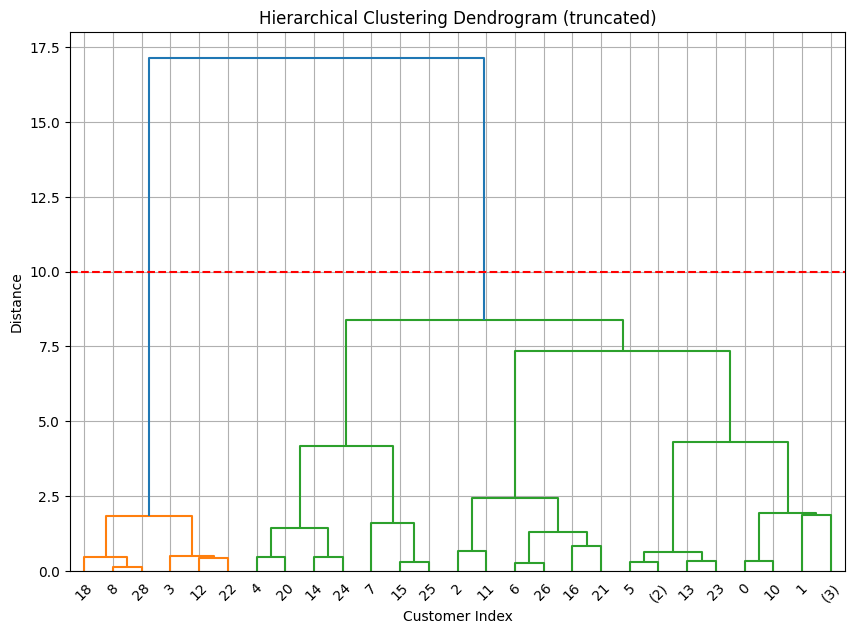

In [ ]:
# Plot dendrogram using scipy's dendrogram()
plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.axhline(y=10, color='red', linestyle='--')
plt.grid(visible=True)
plt.show()


### 8.3 Fit AgglomerativeClustering

<Figure size 1000x700 with 0 Axes>

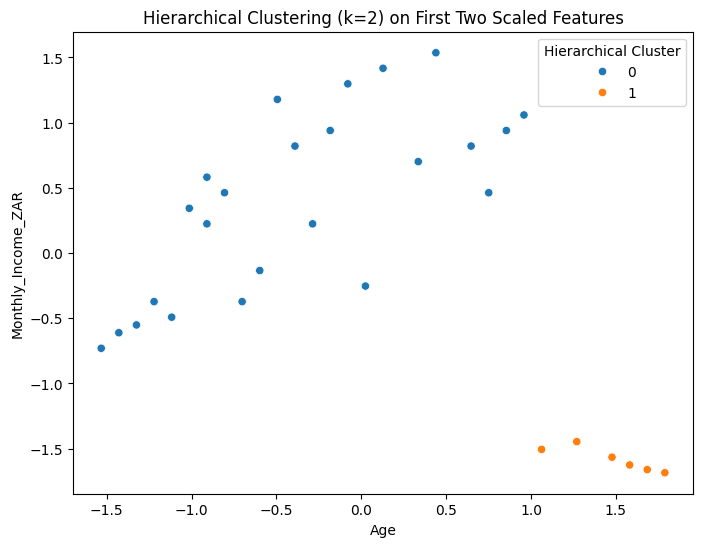

Hierarchical cluster counts:
Hierarchical_Cluster
0    24
1     6
Name: count, dtype: int64


In [ ]:
agg_clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
hier_labels = agg_clustering.fit_predict(X_scaled_df)
banking_df['Hierarchical_Cluster'] = hier_labels

# Visualise hierarchical cluster assignments on the first two scaled features
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_scaled_df.iloc[:, 0],
    y=X_scaled_df.iloc[:, 1],
    hue=hier_labels,
    palette='tab10',
    legend='full'
)
plt.title(f'Hierarchical Clustering (k={k}) on First Two Scaled Features')
plt.xlabel(X_scaled_df.columns[0])
plt.ylabel(X_scaled_df.columns[1])
plt.legend(title='Hierarchical Cluster')
plt.show()

print("Hierarchical cluster counts:")
print(banking_df['Hierarchical_Cluster'].value_counts())

### 8.4 Compare K-Means vs Hierarchical

In [ ]:
# Cross-tabulate: pd.crosstab(df['KMeans_Cluster'], df['Hierarchical_Cluster'])
crosstab = pd.crosstab(banking_df['KMeans_Cluster'], banking_df['Hierarchical_Cluster'])
print("Cross-tabulation of KMeans vs Hierarchical Clusters:")
print(crosstab)


Cross-tabulation of KMeans vs Hierarchical Clusters:
Hierarchical_Cluster   0  1
KMeans_Cluster             
0                     24  0
1                      0  6


The cross tabulation indicates a perfect agreement between K-means and hierachical clustering. A well defined cluster structure is shown in the data, and the agreement between the two methods confirms the robustness and stability of the two clusters. Since hieracical clustering using Ward linkage in deterministc and minimises within cluster variance, it may be considered as being more reliable.

---
## 9. PCA Visualisation
Reduce all features to 2 dimensions so every customer can be plotted
and cluster separation can be inspected visually.

### 9.1 Fit PCA (2 components)

In [ ]:
# PCA for 2D visualization of clusters
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=rseed)
pca_coords = pca.fit_transform(X_scaled_df)
banking_df['PC1'] = pca_coords[:, 0]
banking_df['PC2'] = pca_coords[:, 1]


### 9.2 Scree plot — explained variance

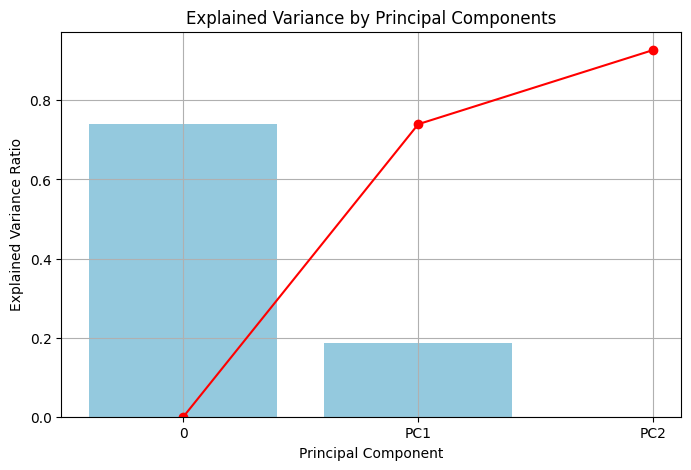

In [ ]:
# Plot explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(8, 5))
sns.barplot(x=[1, 2], y=explained_variance, color='skyblue')
plt.plot([0, 1, 2], [0] + cumulative_variance.tolist(), marker='o', color='red')
plt.xticks([0, 1, 2], ['0', 'PC1', 'PC2'])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.grid(visible=True)
plt.show()


### 9.3 Scatter — K-Means clusters

/Users/Nokukhanya/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


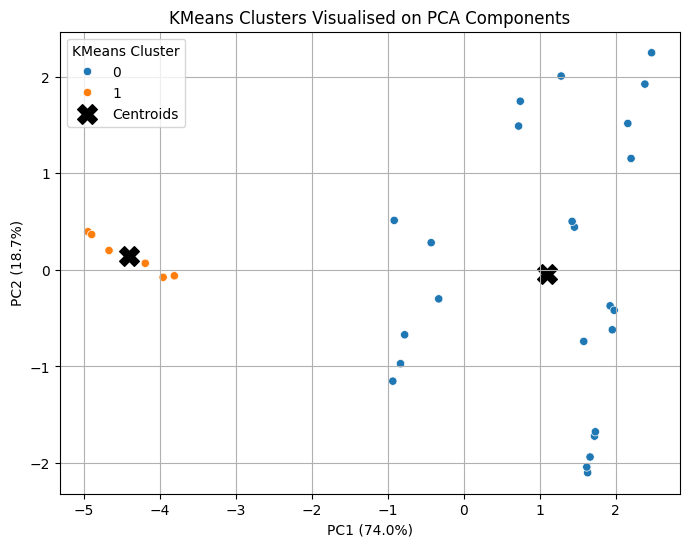

In [ ]:
# Visualise KMeans clusters on PCA components
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    data=banking_df,
    palette='tab10',
    legend='full'
)
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='black', label='Centroids')
plt.title(f'KMeans Clusters Visualised on PCA Components')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.legend(title='KMeans Cluster')
plt.grid(visible=True)
plt.show()


### 9.4 Scatter — Hierarchical clusters

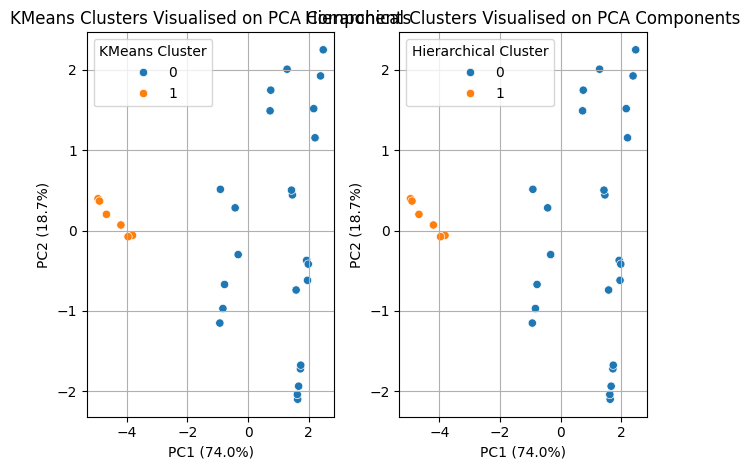

In [148]:
# Visualise both KMeans and Hierarchical clusters on PCA components side by side
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    data=banking_df,
    palette='tab10',
    legend='full'
)
plt.title(f'KMeans Clusters Visualised on PCA Components')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.legend(title='KMeans Cluster')
plt.grid(visible=True)
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Hierarchical_Cluster',
    data=banking_df,
    palette='tab10',
    legend='full'
)
plt.title(f'Hierarchical Clusters Visualised on PCA Components')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.legend(title='Hierarchical Cluster')
plt.grid(visible=True)
plt.tight_layout()
plt.show()


### 9.5 Feature loadings

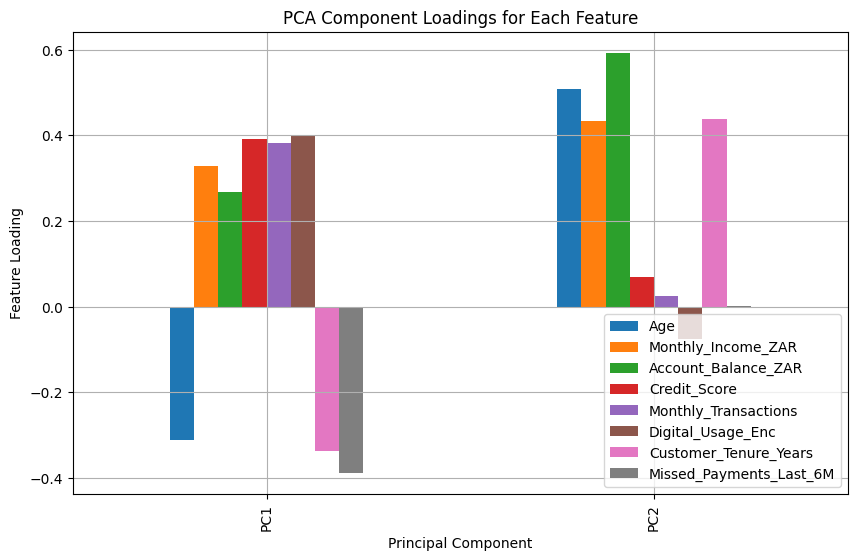

In [ ]:
# PCA component loadings
components_df = pd.DataFrame(pca.components_, columns=X.columns, index=['PC1', 'PC2'])
components_df.plot(kind='bar', figsize=(10, 6))
plt.title('PCA Component Loadings for Each Feature')
plt.xlabel('Principal Component')
plt.ylabel('Feature Loading')
plt.grid(visible=True)
plt.show()


When you look at the PCA and clustering results together, both k-means and hierarchical clustering consistently reveal two clear groups, separated mainly along the first principal component (PC1). PC1 is most influenced by account balance, monthly income, customer tenure, digital usage, and credit score, which means the clustering is largely driven by differences in financial strength and engagement.
Customers with higher PC1 scores stand out as high-value clients, they tend to have larger balances, higher incomes, longer relationships with the bank, and stronger digital engagement. On the other hand, customers with lower PC1 scores represent lower value or less engaged segments, with smaller balances, lower incomes, and a greater likelihood of missed payments.

PC2 plays more of a supporting role, capturing variation within clusters rather than driving the main split. It is shaped by age, account balance, and tenure, suggesting that differences in customer maturity exist inside each group but don’t define the overall segmentation.

Taken together, the alignment between the clustering methods and the strong influence of PC1 confirms that the dataset naturally divides into two distinct customer segments, one financially strong and engaged, the other more vulnerable and less active.

---
## 10. Segment Profiling

### 10.1 Mean feature values per cluster

In [ ]:
# Compute cluster profiles (mean values of features per cluster)
cluster_profiles = banking_df.groupby('KMeans_Cluster')[CLUSTER_FEATURES].mean().round(2).T
print("Cluster Profiles (mean values of features per cluster):")
print(cluster_profiles)


Cluster Profiles (mean values of features per cluster):
KMeans_Cluster                  0        1
Age                         34.21    52.00
Monthly_Income_ZAR       21437.50  4866.67
Account_Balance_ZAR       9329.17  1433.33
Credit_Score               688.54   517.50
Monthly_Transactions        42.17     9.50
Digital_Usage_Enc            1.67     0.00
Customer_Tenure_Years        4.42    10.67
Missed_Payments_Last_6M      0.88     4.50


### 10.2 Radar chart — cluster profiles

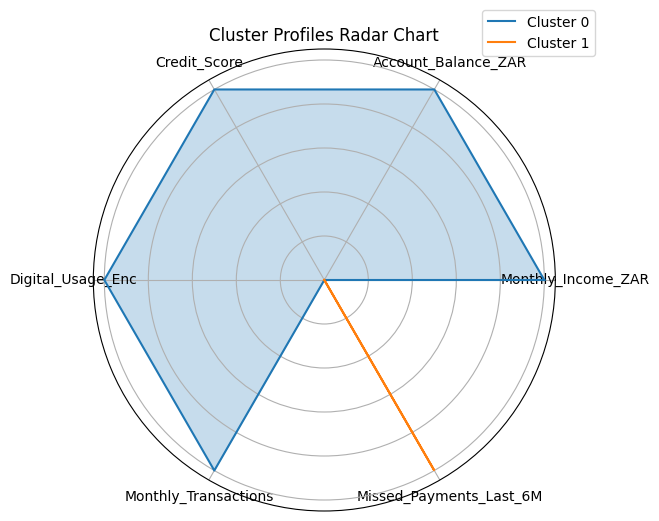

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

features = [
    "Monthly_Income_ZAR",
    "Account_Balance_ZAR",
    "Credit_Score",
    "Digital_Usage_Enc",
    "Monthly_Transactions",
    "Missed_Payments_Last_6M"
]        

centers = centers_original[features]
centers_norm = (centers - centers.min()) / (centers.max() - centers.min())

num_vars = len(features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

for i, row in centers_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f"Cluster {i}")
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)
ax.set_yticklabels([])
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.title("Cluster Profiles Radar Chart")
plt.show()


The segmentation with K=2 has essentially split the dataset into “high-value, digitally engaged customers” vs “low-value, financially vulnerable customers.” The radar chart makes this distinction visually obvious, showing how one group consistently scores high across positive financial/engagement metrics, while the other scores low and is defined by missed payments.

### 10.4 Categorical breakdown per cluster

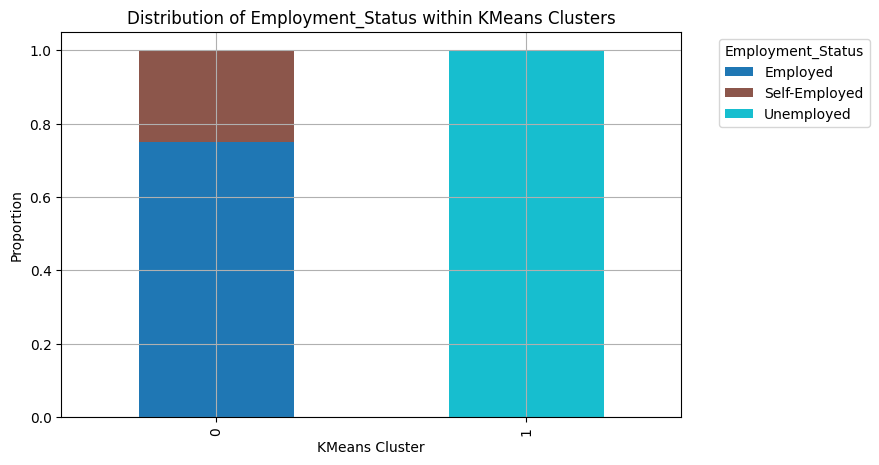

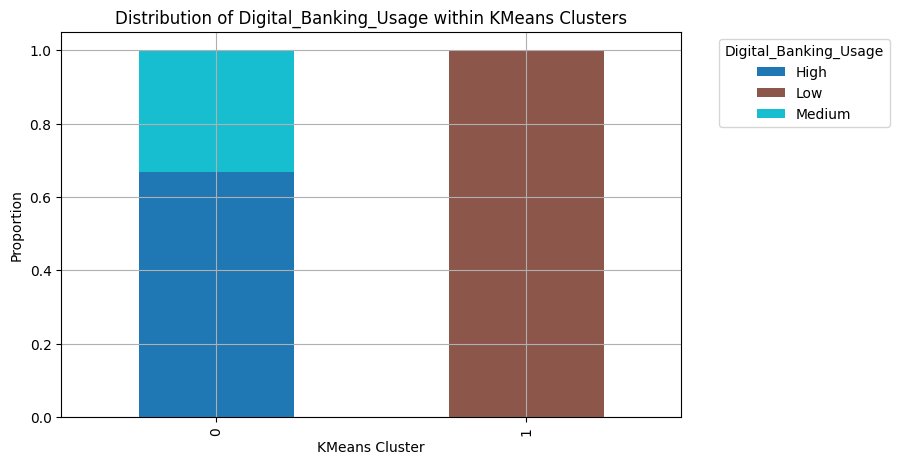

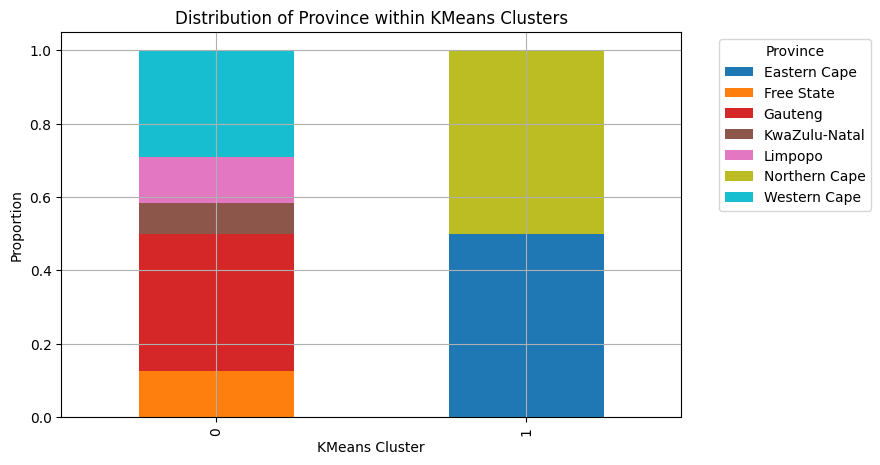

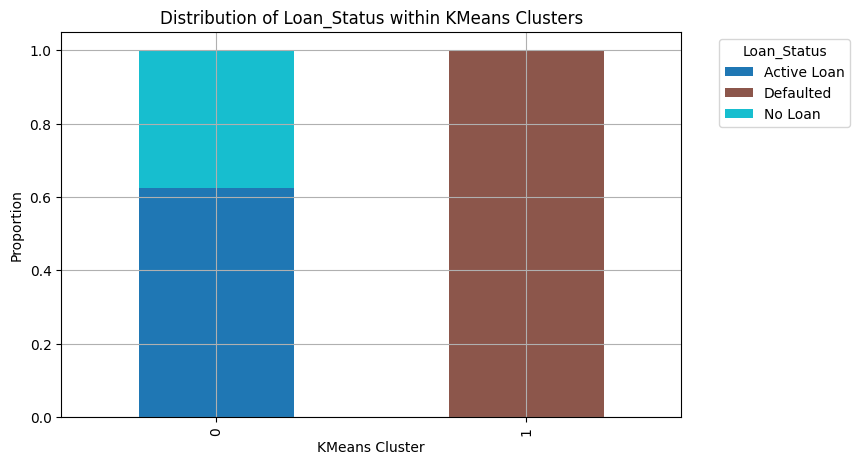

In [ ]:
# Stacked bar charts for categorical features by KMeans cluster
stacked_features = ['Employment_Status', 'Digital_Banking_Usage', 'Province', 'Loan_Status']
for feature in stacked_features:
    crosstab = pd.crosstab(banking_df['KMeans_Cluster'], banking_df[feature], normalize='index')
    crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab10')
    plt.title(f'Distribution of {feature} within KMeans Clusters')
    plt.xlabel('KMeans Cluster')
    plt.ylabel('Proportion')
    plt.legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(visible=True)
    plt.show()


### 10.5 Segment summary table

In [ ]:
# Summarise cluster characteristics with counts, means of numeric features, and modes of categorical features
cluster_summary = banking_df.groupby('KMeans_Cluster').agg(
    Count=('Customer_ID', 'count'),
    Avg_Income=('Monthly_Income_ZAR', 'mean'),
    Avg_Credit_Score=('Credit_Score', 'mean'),
    Avg_Balance=('Account_Balance_ZAR', 'mean'),
    Avg_Missed_Payments=('Missed_Payments_Last_6M', 'mean'),
    Common_Province=('Province', lambda x: x.mode()[0]),
    Common_Employment=('Employment_Status', lambda x: x.mode()[0])
).reset_index()
cluster_summary['% of Portfolio'] = (cluster_summary['Count'] / cluster_summary['Count'].sum() * 100).round(2)
print("Cluster Summary:")
print(cluster_summary[['KMeans_Cluster', 'Count', '% of Portfolio', 'Avg_Income', 'Avg_Credit_Score', 'Avg_Balance', 'Avg_Missed_Payments', 'Common_Province', 'Common_Employment']])


Cluster Summary:
   KMeans_Cluster  Count  % of Portfolio    Avg_Income  Avg_Credit_Score  \
0               0     24            80.0  21437.500000        688.541667   
1               1      6            20.0   4866.666667        517.500000   

   Avg_Balance  Avg_Missed_Payments Common_Province Common_Employment  
0  9329.166667                0.875         Gauteng          Employed  
1  1433.333333                4.500    Eastern Cape        Unemployed  


---
## 11. Product Mapping
Translate segment profiles into actionable banking product recommendations.

| Segment trait | Potential product fit |
|---|---|
| High income, high balance | Investment accounts, private banking, wealth management |
| Young, low balance | Entry savings, budgeting tools, first credit card |
| High transactions, digital | Premium credit card, cashback rewards, mobile-first products |
| Missed payments, low income | Debt counselling, micro-loan restructuring, financial literacy |
| Long-tenured, stable | Loyalty rewards, home loan refinancing, retirement products |
| Self-employed | Business accounts, invoice financing, flexible overdraft |

In [ ]:
# Create simple mapping based on characteristics of each cluster
PRODUCT_MAP = {
    'Cluster 0': ['Premium Credit Card', 'Personal Loan', 'Wealth Management'],
    'Cluster 1': ['Basic Credit Card', 'Home Loan', 'Savings Account'],
    'Cluster 2': ['Business Credit Card', 'Commercial Loan', 'Investment Portfolio']
}
# Print the product recommendations for each cluster
for cluster, products in PRODUCT_MAP.items():
    print(f"{cluster} recommendations: {', '.join(products)}")
    

Cluster 0 recommendations: Premium Credit Card, Personal Loan, Wealth Management
Cluster 1 recommendations: Basic Credit Card, Home Loan, Savings Account
Cluster 2 recommendations: Business Credit Card, Commercial Loan, Investment Portfolio


In [ ]:
# Map cluster labels to segment names and recommended products
banking_df['Segment_Name'] = banking_df['KMeans_Cluster'].apply(lambda x: f"Cluster {x}")
banking_df['Recommended_Products'] = banking_df['Segment_Name'].map(PRODUCT_MAP)
# Print a sample of customers with their assigned segment and recommended products
print(banking_df[['Customer_ID', 'Segment_Name', 'Recommended_Products']].head(10))



    Customer_ID Segment_Name  \
0          1001    Cluster 0   
1          1002    Cluster 0   
2          1003    Cluster 0   
3          1004    Cluster 1   
4          1005    Cluster 0   
6          1006    Cluster 0   
7          1007    Cluster 0   
8          1008    Cluster 0   
9          1009    Cluster 1   
10         1010    Cluster 0   

                                 Recommended_Products  
0   [Premium Credit Card, Personal Loan, Wealth Ma...  
1   [Premium Credit Card, Personal Loan, Wealth Ma...  
2   [Premium Credit Card, Personal Loan, Wealth Ma...  
3     [Basic Credit Card, Home Loan, Savings Account]  
4   [Premium Credit Card, Personal Loan, Wealth Ma...  
6   [Premium Credit Card, Personal Loan, Wealth Ma...  
7   [Premium Credit Card, Personal Loan, Wealth Ma...  
8   [Premium Credit Card, Personal Loan, Wealth Ma...  
9     [Basic Credit Card, Home Loan, Savings Account]  
10  [Premium Credit Card, Personal Loan, Wealth Ma...  


/var/folders/kt/dcg5f6cn75gbp4v4bjb3jw940000gn/T/ipykernel_64770/1588918709.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='tab10')


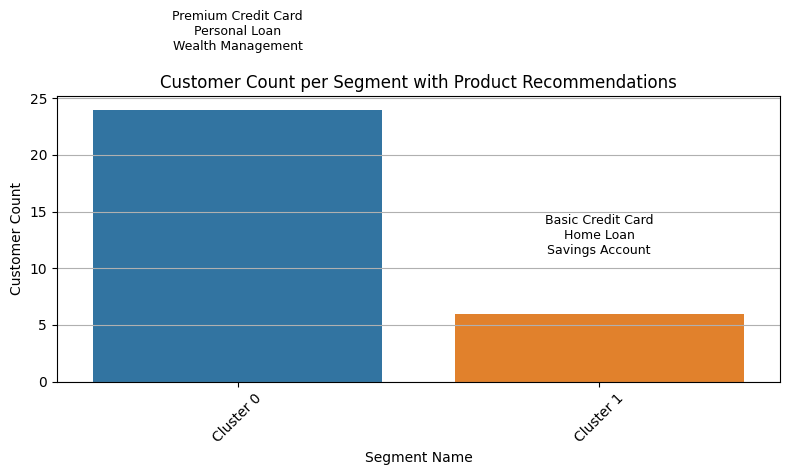

In [ ]:
# Visualise segment counts with product recommendations annotated
segment_counts = banking_df['Segment_Name'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='tab10')
plt.title('Customer Count per Segment with Product Recommendations')
plt.xlabel('Segment Name')
plt.ylabel('Customer Count')
plt.xticks(rotation=45)

for i, count in enumerate(segment_counts.values):
    segment = segment_counts.index[i]
    products = PRODUCT_MAP.get(segment, [])
    plt.text(i, count + 5, '\n'.join(products), ha='center', va='bottom', fontsize=9)
plt.grid(visible=True, axis='y')
plt.tight_layout()
plt.show()


### 11.1 Your product strategy
Between the two clusters Cluster 0 depicts how the customers demonstrate higher balances, stronger digital usage and healthier credit metrics. This best relays into providing premium credit cards, tailored personal loans and wealth management offerings will help deepen relationships and capture more wallet share.
Cluster 1 appears more value-sensitive and stability-focused, with lower balances and a greater need for financial support, here basic credit cards, home loan guidance and accessible savings account solutions are more appropriate to build resilience and reduce risk.

---
## 12. Export Results

### 12.1 Export labelled customer data

In [ ]:
# Export segmentation results to CSV
export_columns = list(banking_df.columns)
banking_df.to_csv('segmentation_results.csv', columns=export_columns, index=False)
print("Segmentation results exported to 'segmentation_results.csv'")


Segmentation results exported to 'segmentation_results.csv'


### 12.2 Export segment summary

In [ ]:
# Export cluster summary to CSV
cluster_summary.to_csv('segment_profiles.csv', index=False)
print("Segment profiles exported to 'segment_profiles.csv'")


Segment profiles exported to 'segment_profiles.csv'
